In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

In [3]:
SEED = 12

In [4]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [5]:
pizza.head()

,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
order_details_id,,,,,,,,,,,
1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [8]:
pizza['order_hour'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S').dt.hour
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

In [10]:
conteo = pizza.groupby(['order_date', 'order_hour']).size().reset_index(name='n_orders')
obs = conteo['n_orders'].values

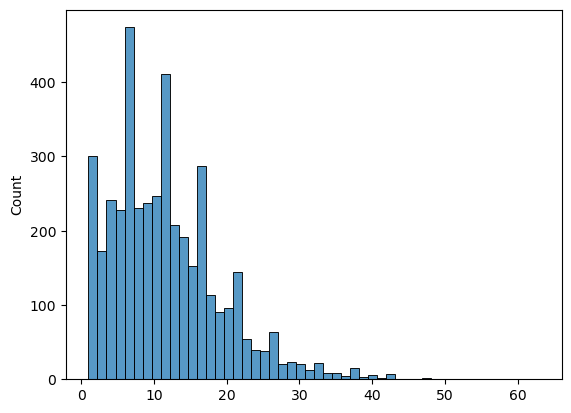

In [11]:
sns.histplot(obs);

In [12]:
k=2

with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=np.quantile(obs, np.linspace(0.1, 0.9, k)), sigma=5, shape=k, transform=pm.distributions.transforms.ordered)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 83 seconds.


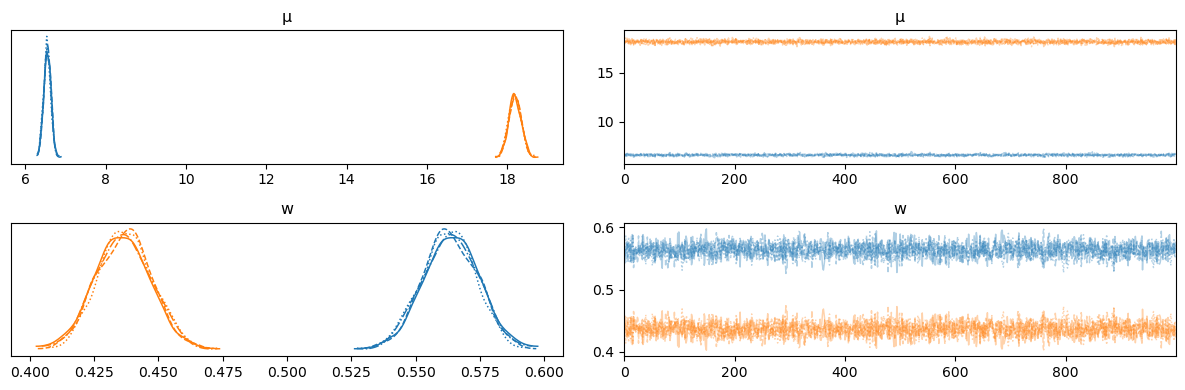

In [13]:
az.plot_trace(idata)
plt.tight_layout();

In [14]:
with poisson_mixture_model:
    pm.sample_posterior_predictive(idata, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

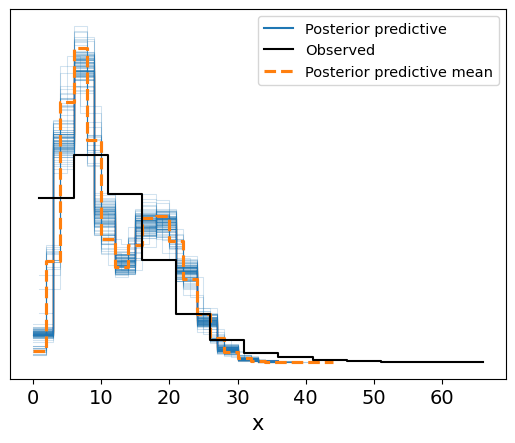

In [15]:
az.plot_ppc(idata, num_pp_samples=100);